# Identificação de Bancos de Areia no Rio Tapajós com U-Net

Segmentação semântica de bancos de areia usando imagens multiespectrais Sentinel-2 (B2, B3, B4, B8, B11, B12) e a arquitetura U-Net em PyTorch.

**Estrutura esperada dos dados:**
```
images/<id>.tif   -> imagem com 6 bandas empilhadas (bandas, H, W)
masks/<id>.tif    -> máscara binária (H, W), 1 = banco de areia
```


## 1. Imports

In [2]:
import os
import glob
import random

import numpy as np
import rasterio  # leitura de imagens multiespectrais (GeoTIFF)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## 2. Configuração
Ajuste os caminhos e hiperparâmetros aqui.

In [3]:
CONFIG = {
    "images_dir": "/kaggle/input/datasets/gabrielalvesdsa/bancos-de-areia/bancos-de-areia/images",
    "masks_dir": "/kaggle/input/datasets/gabrielalvesdsa/bancos-de-areia/bancos-de-areia/masks",
    "bands": ["B2", "B3", "B4", "B8", "B11", "B12"],

    "img_size": 144,

    "batch_size": 8,
    "epochs": 40,
    "lr": 1e-3,
    "grad_clip": 1.0,   # limite de norma do gradiente, evita explosão -> NaN

    "val_split": 0.15,
    "test_split": 0.15,

    "checkpoint_path": "/kaggle/working/unet_bancos_areia.pt",
}


## 3. Dataset

**Correção importante:** imagens de satélite costumam ter pixels `NaN` nas áreas de "nodata"
(bordas da cena, regiões mascaradas). `np.clip` **não remove `NaN`**, então esses valores
passavam direto para a rede e explodiam a loss (`loss = nan` já na primeira época).
Agora qualquer `NaN`/`Inf` é substituído por `0` logo após a leitura, antes de normalizar.

In [4]:
class BancosAreiaDataset(Dataset):

    def __init__(self, pares, img_size=144, augment=False):
        self.pares = pares
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.pares)

    def _read_image(self, path):
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # (bandas, H, W)
        # CORREÇÃO: remove NaN/Inf (pixels de nodata) antes de qualquer operação
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        return img

    def _read_mask(self, path):
        with rasterio.open(path) as src:
            mask = src.read(1).astype(np.float32)  # (H, W)
        mask = np.nan_to_num(mask, nan=0.0, posinf=0.0, neginf=0.0)
        return mask

    def _normalize(self, img):
        # reflectância Sentinel-2 costuma vir em 0-10000; já sem NaN, o clip funciona corretamente
        img = np.clip(img, 0, 10000)
        return img / 10000.0

    def _center_crop_or_pad(self, arr):
        size = self.img_size
        if arr.ndim == 2:
            h, w = arr.shape
        else:
            _, h, w = arr.shape

        pad_h = max(size - h, 0)
        pad_w = max(size - w, 0)
        pad_top, pad_bottom = pad_h // 2, pad_h - pad_h // 2
        pad_left, pad_right = pad_w // 2, pad_w - pad_w // 2

        if arr.ndim == 2:
            arr = np.pad(arr, ((pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)
            h, w = arr.shape
        else:
            arr = np.pad(arr, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right)), mode="constant", constant_values=0)
            _, h, w = arr.shape

        top = (h - size) // 2
        left = (w - size) // 2
        if arr.ndim == 2:
            return arr[top:top + size, left:left + size]
        return arr[:, top:top + size, left:left + size]

    def __getitem__(self, idx):
        image_path, mask_path = self.pares[idx]

        img = self._read_image(image_path)
        mask = self._read_mask(mask_path)

        img = self._normalize(img)
        img = self._center_crop_or_pad(img)
        mask = self._center_crop_or_pad(mask)
        mask = (mask > 0).astype(np.float32)

        # augmentação simples (flip), só no treino
        if self.augment and random.random() > 0.5:
            img = img[:, :, ::-1].copy()
            mask = mask[:, ::-1].copy()
        if self.augment and random.random() > 0.5:
            img = img[:, ::-1, :].copy()
            mask = mask[::-1, :].copy()

        img_t = torch.from_numpy(img)                 # (bandas, H, W)
        mask_t = torch.from_numpy(mask).unsqueeze(0)   # (1, H, W)
        return img_t, mask_t


## 4. Pareamento imagem ↔ máscara e verificação de consistência

In [5]:
image_paths = glob.glob(os.path.join(CONFIG["images_dir"], "*.tif"))
mask_paths = glob.glob(os.path.join(CONFIG["masks_dir"], "**", "*.tif"), recursive=True)

imagens_por_id = {os.path.splitext(os.path.basename(p))[0]: p for p in image_paths}
mascaras_por_id = {os.path.splitext(os.path.basename(p))[0]: p for p in mask_paths}

ids_imagens = set(imagens_por_id)
ids_mascaras = set(mascaras_por_id)

faltando_mascara = ids_imagens - ids_mascaras
faltando_imagem = ids_mascaras - ids_imagens

print("Imagens:", len(ids_imagens))
print("Máscaras:", len(ids_mascaras))
print("Sem máscara:", len(faltando_mascara))
print("Sem imagem:", len(faltando_imagem))

if faltando_mascara or faltando_imagem:
    raise ValueError("Há inconsistência entre imagens e máscaras.")

ids = sorted(ids_imagens)
pares = [(imagens_por_id[i], mascaras_por_id[i]) for i in ids]
print("Total de pares:", len(pares))


Imagens: 200
Máscaras: 200
Sem máscara: 0
Sem imagem: 0
Total de pares: 200


## 5. Checagem de integridade dos dados

**Novo passo:** varre todas as imagens em busca de `NaN`/`Inf` no arquivo original.
Isso não impede o treino (já corrigimos o dataset), mas avisa quantas cenas tinham
pixels de nodata, o que ajuda a confirmar a causa do erro anterior.

In [6]:
def tem_valor_invalido(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    return bool(np.isnan(arr).any() or np.isinf(arr).any())

qtd_com_nan = sum(tem_valor_invalido(img_path) for img_path, _ in pares)
print(f"Imagens com NaN/Inf no arquivo original: {qtd_com_nan} de {len(pares)}")


Imagens com NaN/Inf no arquivo original: 73 de 200


## 6. Split estratificado (treino / validação / teste)
Estratifica por presença ou não de banco de areia na máscara, para manter a proporção de classes em cada conjunto.

In [7]:
def mascara_tem_banco(caminho_mascara):
    with rasterio.open(caminho_mascara) as src:
        mascara = np.nan_to_num(src.read(1))
    return int(np.any(mascara > 0))

labels = np.array([mascara_tem_banco(m) for _, m in pares])
print("Total:", len(pares), "| Positivas:", int(labels.sum()), "| Negativas:", int(len(labels) - labels.sum()))

indices = np.arange(len(pares))

train_idx, temp_idx = train_test_split(
    indices, test_size=CONFIG["val_split"] + CONFIG["test_split"],
    stratify=labels, random_state=SEED
)
temp_labels = labels[temp_idx]
proporcao_test = CONFIG["test_split"] / (CONFIG["val_split"] + CONFIG["test_split"])
val_idx, test_idx = train_test_split(
    temp_idx, test_size=proporcao_test, stratify=temp_labels, random_state=SEED
)

train_pares = [pares[i] for i in train_idx]
val_pares = [pares[i] for i in val_idx]
test_pares = [pares[i] for i in test_idx]

train_ds = BancosAreiaDataset(train_pares, img_size=CONFIG["img_size"], augment=True)
val_ds = BancosAreiaDataset(val_pares, img_size=CONFIG["img_size"], augment=False)
test_ds = BancosAreiaDataset(test_pares, img_size=CONFIG["img_size"], augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

def contar_classes(idx):
    y = labels[idx]
    return int(y.sum()), int(len(y) - y.sum())

print("Treino:", len(train_ds), "| pos/neg:", contar_classes(train_idx))
print("Validação:", len(val_ds), "| pos/neg:", contar_classes(val_idx))
print("Teste:", len(test_ds), "| pos/neg:", contar_classes(test_idx))


Total: 200 | Positivas: 50 | Negativas: 150
Treino: 140 | pos/neg: (35, 105)
Validação: 30 | pos/neg: (8, 22)
Teste: 30 | pos/neg: (7, 23)


## 7. Sanity check antes do treino

**Novo passo:** pega um batch real do `train_loader` e confirma que não há `NaN`/`Inf`
depois do pré-processamento. Se isso passar, a causa raiz do `loss = nan` foi eliminada.

In [8]:
sample_imgs, sample_masks = next(iter(train_loader))
print("Shape imagens:", sample_imgs.shape, "| Shape máscaras:", sample_masks.shape)
print("Contém NaN (imagens)?", torch.isnan(sample_imgs).any().item())
print("Contém Inf (imagens)?", torch.isinf(sample_imgs).any().item())
print("Min/Max imagens:", sample_imgs.min().item(), sample_imgs.max().item())


Shape imagens: torch.Size([8, 6, 144, 144]) | Shape máscaras: torch.Size([8, 1, 144, 144])
Contém NaN (imagens)? False
Contém Inf (imagens)? False
Min/Max imagens: 0.0 0.5356582403182983


## 8. Arquitetura U-Net
Encoder-decoder com skip connections, entrada de 6 canais (bandas espectrais) e saída de 1 canal (máscara binária).

In [9]:
class DoubleConv(nn.Module):
    # bloco básico: duas convoluções 3x3 + BatchNorm + ReLU
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, base_ch=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.enc3 = DoubleConv(base_ch * 2, base_ch * 4)
        self.enc4 = DoubleConv(base_ch * 4, base_ch * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_ch * 8, base_ch * 16)

        self.up4 = nn.ConvTranspose2d(base_ch * 16, base_ch * 8, 2, stride=2)
        self.dec4 = DoubleConv(base_ch * 16, base_ch * 8)
        self.up3 = nn.ConvTranspose2d(base_ch * 8, base_ch * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_ch * 8, base_ch * 4)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_ch * 4, base_ch * 2)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = DoubleConv(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_channels, 1)  # mapeia para 1 canal (logits)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))  # skip connection
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # logits, sem sigmoid (aplicado na loss/inferência)


model = UNet(in_channels=len(CONFIG["bands"]), out_channels=1).to(device)
print(model)


UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3,

## 9. Loss e Métricas
Combinação de BCE + Dice Loss, e IoU/Dice/Precision/Recall calculados sobre o batch inteiro (pixels concatenados).

In [10]:
def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()


def combined_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss(logits, targets)
    return bce + dice


@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.reshape(-1)
    targets_flat = targets.reshape(-1)

    tp = (preds_flat * targets_flat).sum()
    fp = (preds_flat * (1 - targets_flat)).sum()
    fn = ((1 - preds_flat) * targets_flat).sum()

    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)

    return {
        "iou": iou.item(),
        "dice": dice.item(),
        "precision": precision.item(),
        "recall": recall.item(),
    }


## 10. Loop de Treinamento

**Correções:**
- `torch.nn.utils.clip_grad_norm_` limita a norma do gradiente, evitando que uma amostra ruim
  faça o treino explodir para `NaN`.
- Checagem explícita: se a loss vier `NaN`/`Inf`, o treino para com uma mensagem clara em vez de
  rodar 40 épocas silenciosamente quebradas.

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)

history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}
best_iou = 0.0

for epoch in range(1, CONFIG["epochs"] + 1):
    # --- treino ---
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = combined_loss(logits, masks)

        # CORREÇÃO: para o treino cedo se a loss explodir, em vez de continuar rodando com NaN
        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Loss inválida (NaN/Inf) na época {epoch}. "
                "Verifique se há valores NaN/Inf nos dados de entrada."
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])  # evita explosão de gradiente
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # --- validação ---
    model.eval()
    val_loss, val_iou, val_dice = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = combined_loss(logits, masks)
            val_loss += loss.item() * imgs.size(0)

            metricas = compute_metrics(logits, masks)
            val_iou += metricas["iou"] * imgs.size(0)
            val_dice += metricas["dice"] * imgs.size(0)

    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)

    scheduler.step(val_iou)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    # salva o melhor modelo até agora
    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), CONFIG["checkpoint_path"])

    print(f"Época {epoch:02d} | loss treino: {train_loss:.4f} | loss val: {val_loss:.4f} "
          f"| IoU val: {val_iou:.4f} | Dice val: {val_dice:.4f}")


Época 01 | loss treino: 1.5111 | loss val: 1.5745 | IoU val: 0.0000 | Dice val: 0.0000
Época 02 | loss treino: 1.3699 | loss val: 1.3747 | IoU val: 0.0000 | Dice val: 0.0000
Época 03 | loss treino: 1.2980 | loss val: 1.2963 | IoU val: 0.0323 | Dice val: 0.0604
Época 04 | loss treino: 1.2409 | loss val: 1.2134 | IoU val: 0.0666 | Dice val: 0.1165
Época 05 | loss treino: 1.1927 | loss val: 1.1752 | IoU val: 0.1289 | Dice val: 0.2056
Época 06 | loss treino: 1.1518 | loss val: 1.1161 | IoU val: 0.1132 | Dice val: 0.1856
Época 07 | loss treino: 1.1150 | loss val: 1.0952 | IoU val: 0.1548 | Dice val: 0.2452
Época 08 | loss treino: 1.0896 | loss val: 1.0750 | IoU val: 0.0844 | Dice val: 0.1446
Época 09 | loss treino: 1.0691 | loss val: 1.0553 | IoU val: 0.1841 | Dice val: 0.2916
Época 10 | loss treino: 1.0411 | loss val: 1.0534 | IoU val: 0.0563 | Dice val: 0.1035
Época 11 | loss treino: 1.0289 | loss val: 1.0448 | IoU val: 0.1922 | Dice val: 0.3020
Época 12 | loss treino: 1.0186 | loss val: 

## 11. Curvas de Treinamento

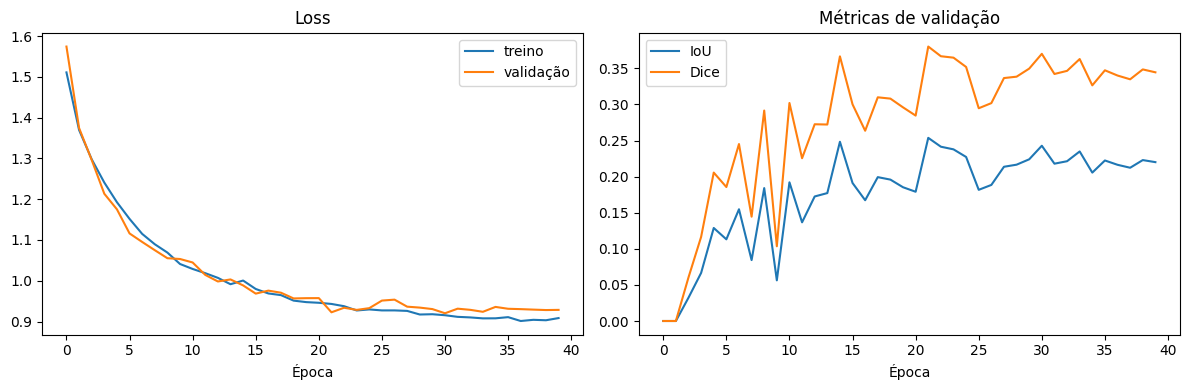

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["train_loss"], label="treino")
ax[0].plot(history["val_loss"], label="validação")
ax[0].set_title("Loss")
ax[0].set_xlabel("Época")
ax[0].legend()

ax[1].plot(history["val_iou"], label="IoU")
ax[1].plot(history["val_dice"], label="Dice")
ax[1].set_title("Métricas de validação")
ax[1].set_xlabel("Época")
ax[1].legend()

plt.tight_layout()
plt.show()


## 12. Avaliação no conjunto de teste

In [13]:
model.load_state_dict(torch.load(CONFIG["checkpoint_path"], map_location=device))
model.eval()

test_iou = test_dice = test_precision = test_recall = 0.0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        metricas = compute_metrics(logits, masks)

        batch_size = imgs.size(0)
        test_iou += metricas["iou"] * batch_size
        test_dice += metricas["dice"] * batch_size
        test_precision += metricas["precision"] * batch_size
        test_recall += metricas["recall"] * batch_size

n_test = len(test_loader.dataset)
test_iou /= n_test
test_dice /= n_test
test_precision /= n_test
test_recall /= n_test

print(f"Teste -> IoU: {test_iou:.4f} | Dice: {test_dice:.4f} "
      f"| Precision: {test_precision:.4f} | Recall: {test_recall:.4f}")


Teste -> IoU: 0.1261 | Dice: 0.1898 | Precision: 0.1488 | Recall: 0.5499


## 13. Visualização de Predições
Mostra a composição RGB (B4, B3, B2), a máscara real e a predição do modelo.

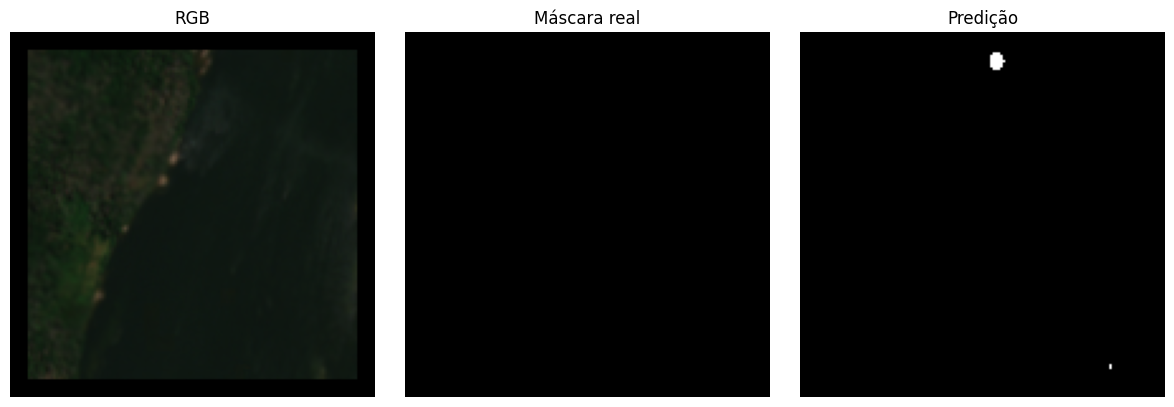

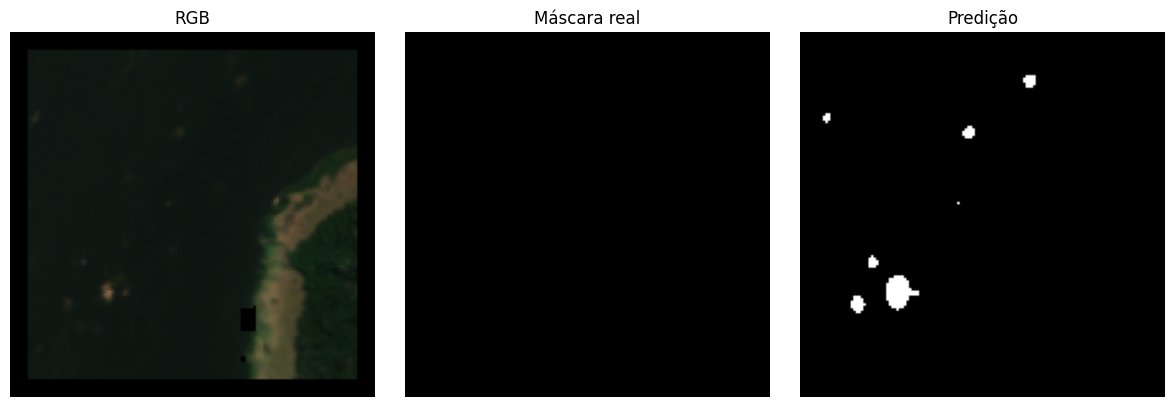

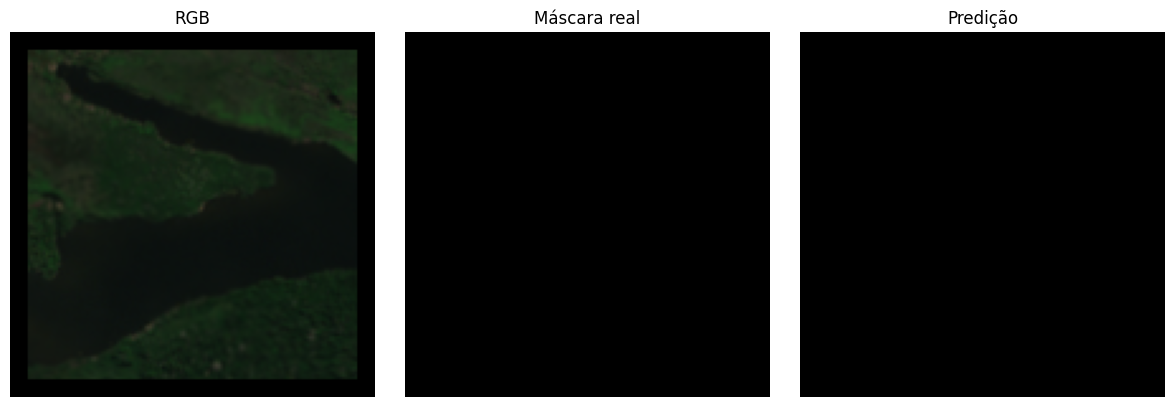

In [14]:
def show_prediction(dataset, model, idx, bands, threshold=0.5):
    img_t, mask_t = dataset[idx]
    with torch.no_grad():
        logits = model(img_t.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > threshold).float().cpu().squeeze().numpy()

    idx_r, idx_g, idx_b = bands.index("B4"), bands.index("B3"), bands.index("B2")
    rgb = img_t[[idx_r, idx_g, idx_b]].permute(1, 2, 0).numpy()
    rgb = np.clip(rgb * 3.0, 0, 1)  # realce simples de contraste

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(rgb); ax[0].set_title("RGB"); ax[0].axis("off")
    ax[1].imshow(mask_t.squeeze().numpy(), cmap="gray"); ax[1].set_title("Máscara real"); ax[1].axis("off")
    ax[2].imshow(pred, cmap="gray"); ax[2].set_title("Predição"); ax[2].axis("off")
    plt.tight_layout()
    plt.show()


for i in range(min(3, len(test_ds))):
    show_prediction(test_ds, model, i, CONFIG["bands"])


In [19]:
def mostrar_positivas_teste(
    dataset,
    model,
    device,
    threshold=0.5
):
    model.eval()

    # Encontrar somente imagens positivas
    indices_positivos = []

    for i in range(len(dataset)):

        _, mask = dataset[i]

        if mask.sum() > 0:
            indices_positivos.append(i)

    print(
        f"Imagens positivas no teste: "
        f"{len(indices_positivos)}"
    )

    # Mostrar cada imagem positiva
    for idx in indices_positivos:

        img, mask = dataset[idx]

        # Adicionar dimensão do batch
        entrada = (
            img
            .unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():

            logits = model(
                entrada
            )

            prob = torch.sigmoid(
                logits
            )[0, 0]

            pred = (
                prob >= threshold
            ).float()

        # Converter para numpy
        img_np = (
            img.cpu().numpy()
        )

        mask_np = (
            mask[0]
            .cpu()
            .numpy()
        )

        pred_np = (
            pred
            .cpu()
            .numpy()
        )

        prob_np = (
            prob
            .cpu()
            .numpy()
        )

        # RGB natural:
        # bandas armazenadas como
        # B02, B03, B04, B08, B11, B12
        rgb = np.stack(
            [
                img_np[2],  # B04
                img_np[1],  # B03
                img_np[0]   # B02
            ],
            axis=-1
        )

        # Melhorar contraste apenas
        # para visualização
        minimo = np.percentile(
            rgb,
            2
        )

        maximo = np.percentile(
            rgb,
            98
        )

        rgb = np.clip(
            (rgb - minimo)
            / (maximo - minimo + 1e-8),
            0,
            1
        )

        # ==========================
        # Figura
        # ==========================

        fig, axes = plt.subplots(
            1,
            5,
            figsize=(22, 5)
        )

        # RGB
        axes[0].imshow(rgb)

        axes[0].set_title(
            "Imagem"
        )

        # Ground truth
        axes[1].imshow(
            mask_np,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[1].set_title(
            "Ground Truth"
        )

        # Probabilidade
        im = axes[2].imshow(
            prob_np,
            cmap="viridis",
            vmin=0,
            vmax=1
        )

        axes[2].set_title(
            "Probabilidade"
        )

        plt.colorbar(
            im,
            ax=axes[2],
            fraction=0.046,
            pad=0.04
        )

        # Predição binária
        axes[3].imshow(
            pred_np,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[3].set_title(
            f"Predição (t={threshold})"
        )

        # Sobreposição
        axes[4].imshow(
            rgb
        )

        pred_overlay = np.ma.masked_where(
            pred_np == 0,
            pred_np
        )

        axes[4].imshow(
            pred_overlay,
            cmap="Reds",
            alpha=0.55,
            vmin=0,
            vmax=1
        )

        axes[4].set_title(
            "Predição sobre RGB"
        )

        for ax in axes:
            ax.axis("off")


        plt.savefig(
            f"/kaggle/working/resultado_{idx}.png",
            dpi=300,
            bbox_inches="tight"
        )
        
        plt.tight_layout()
        plt.show()

Imagens positivas no teste: 7


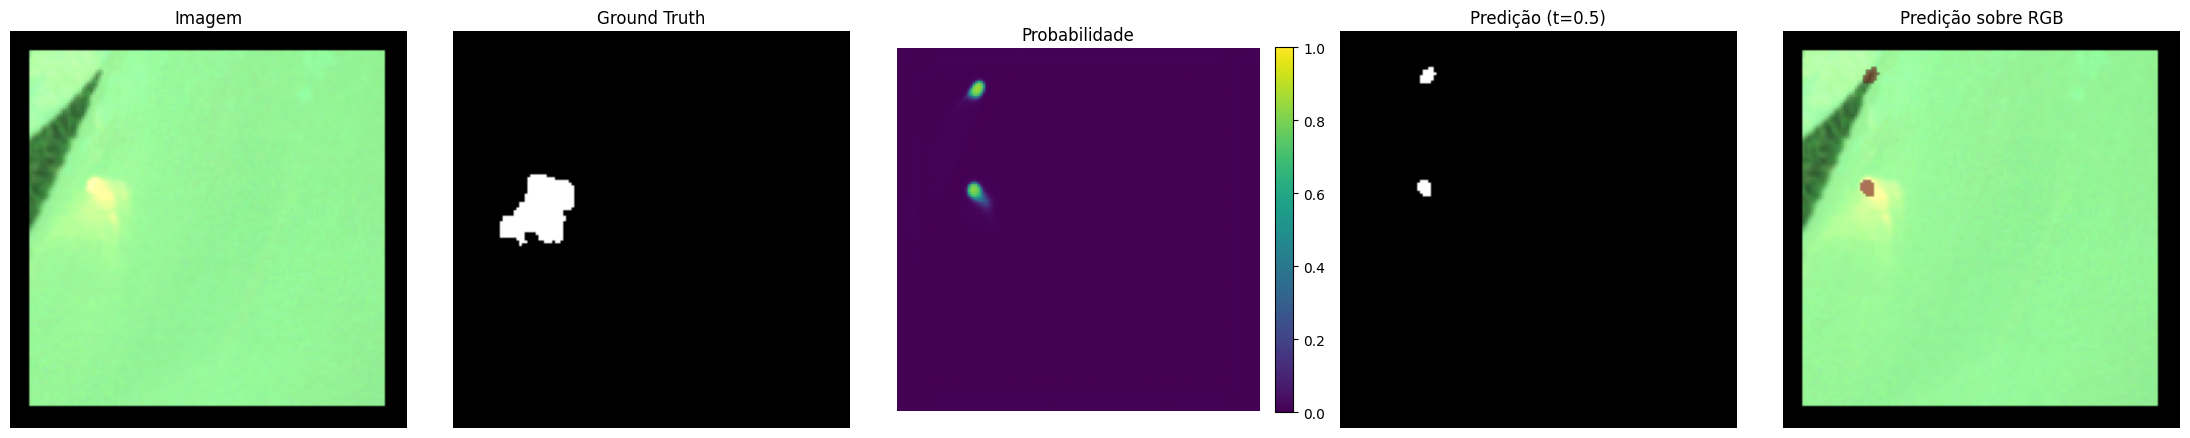

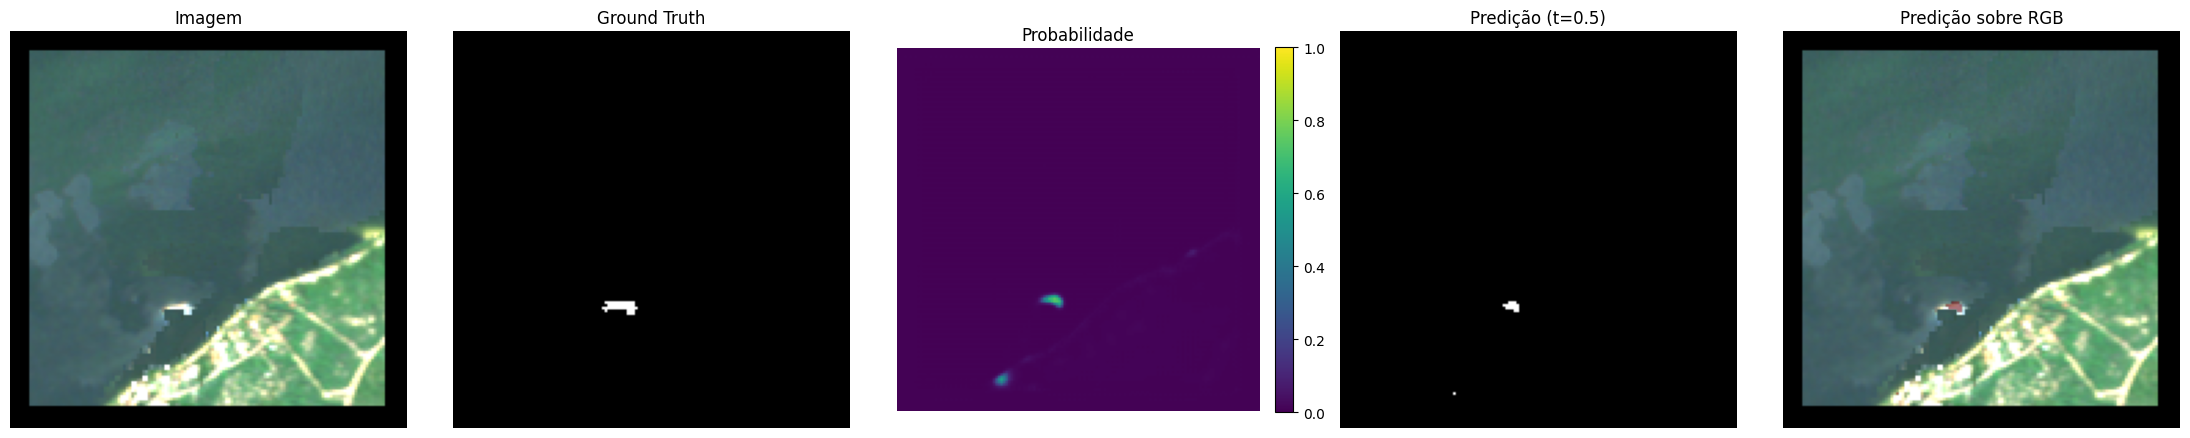

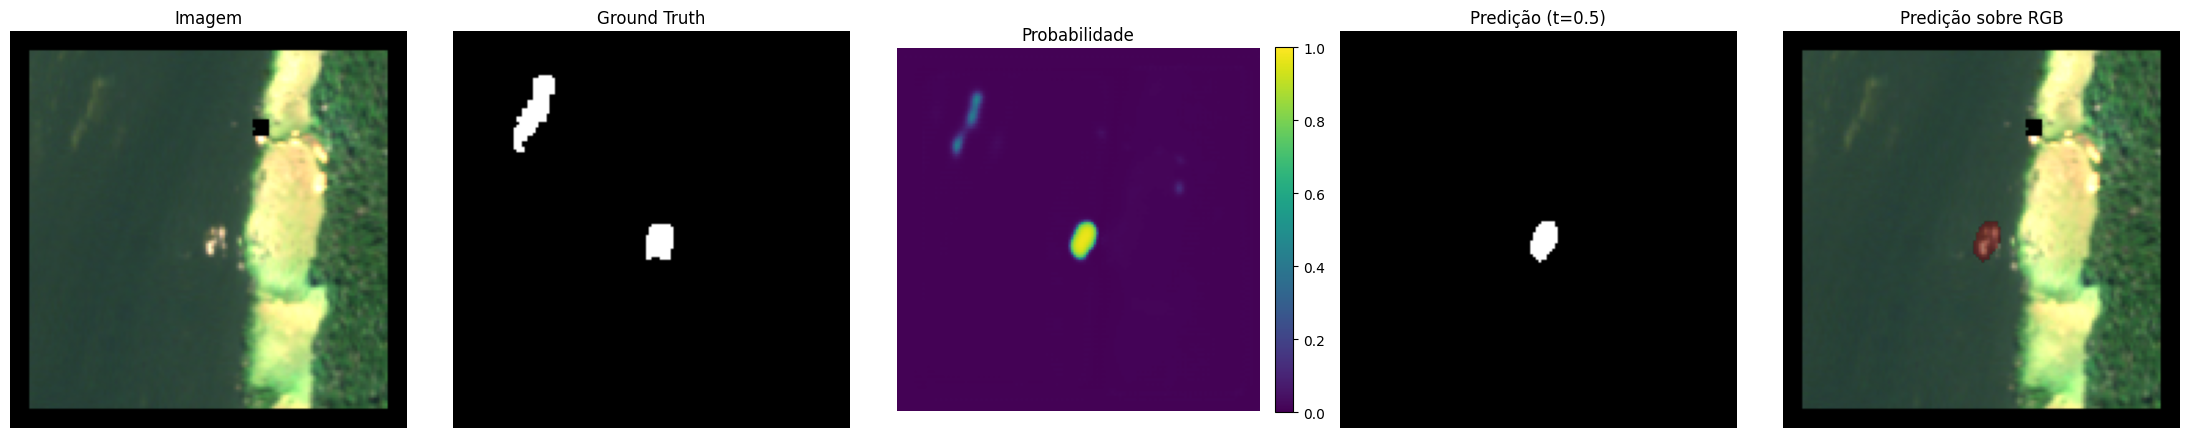

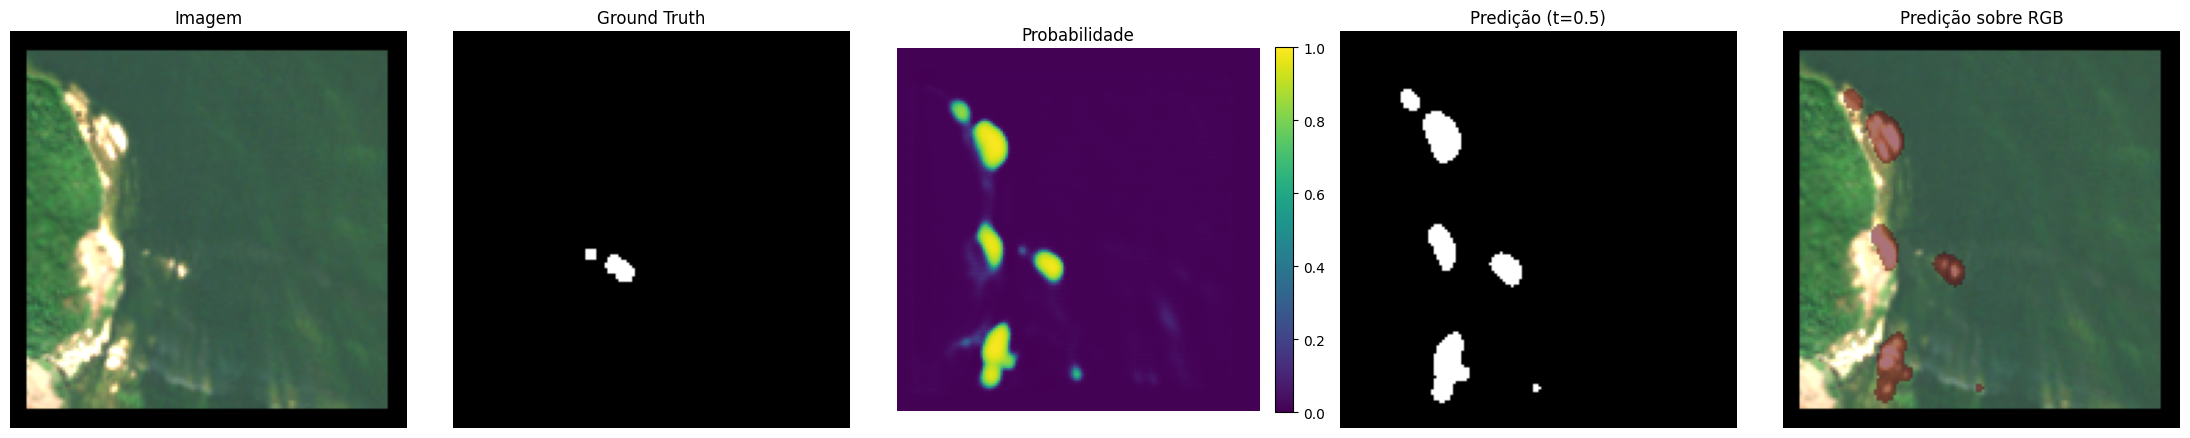

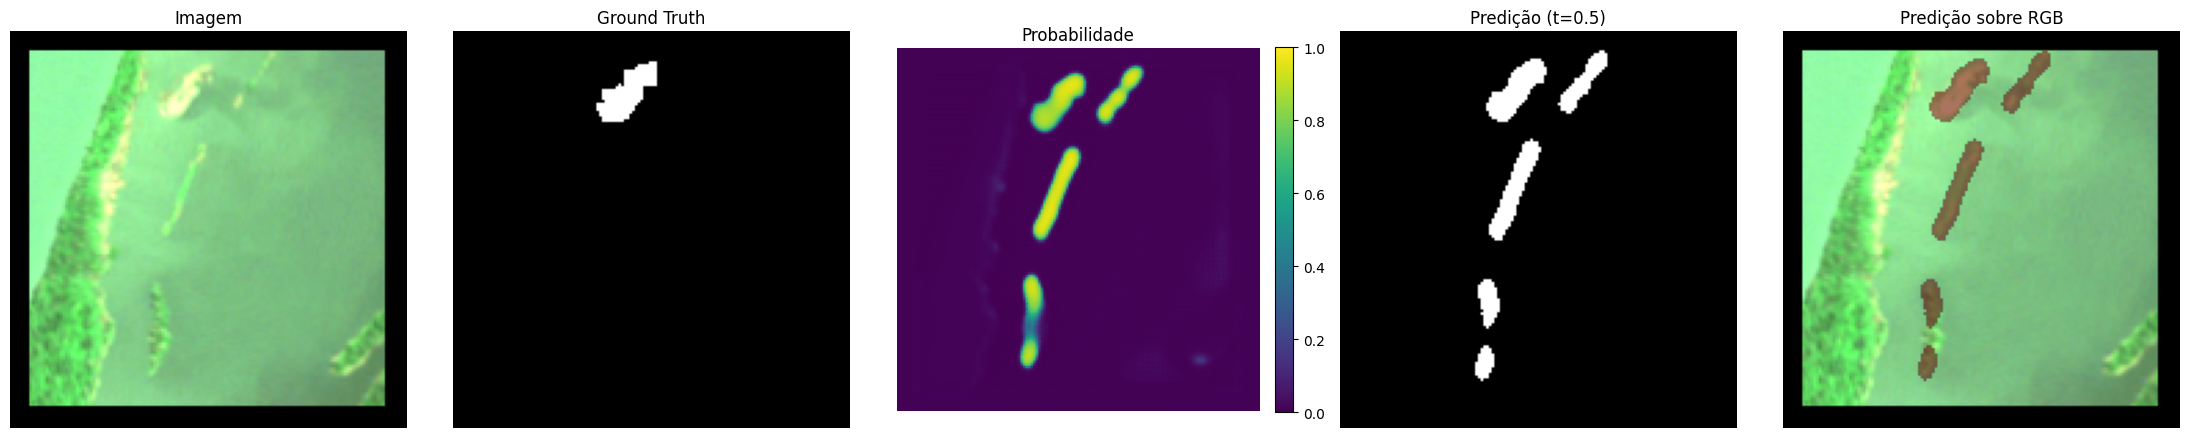

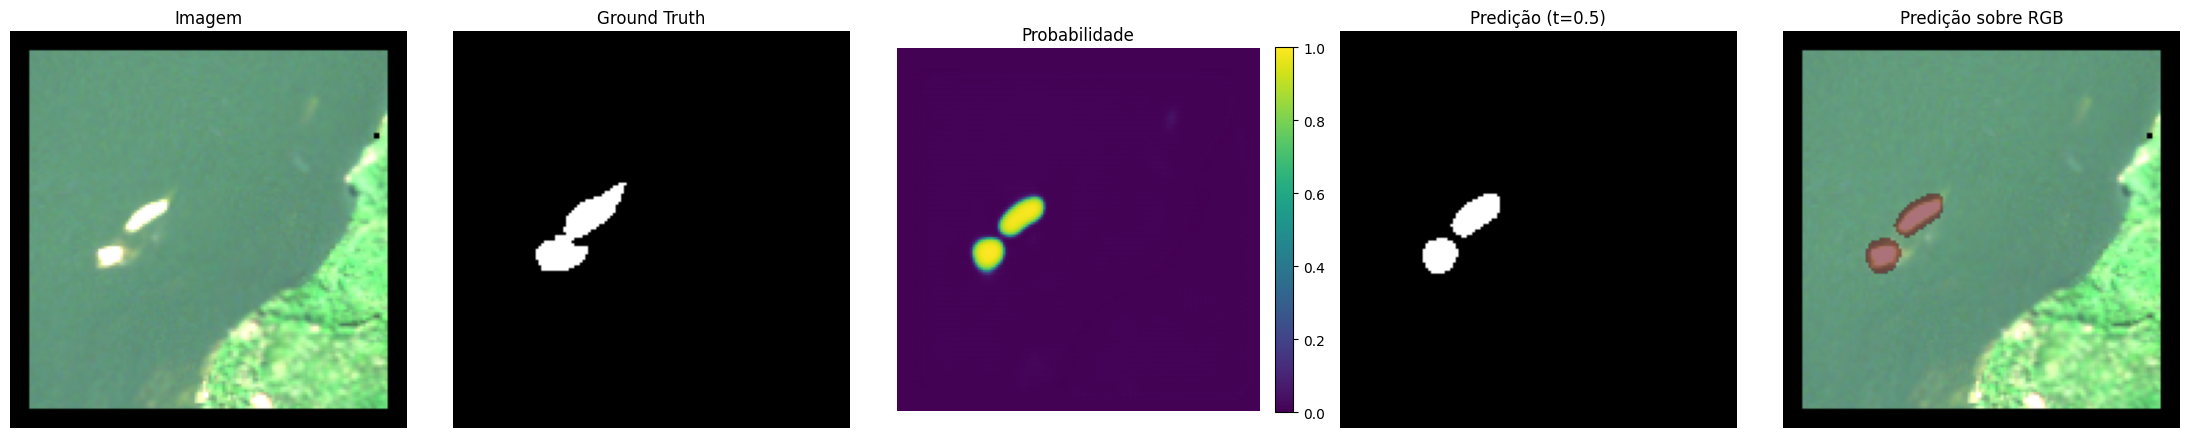

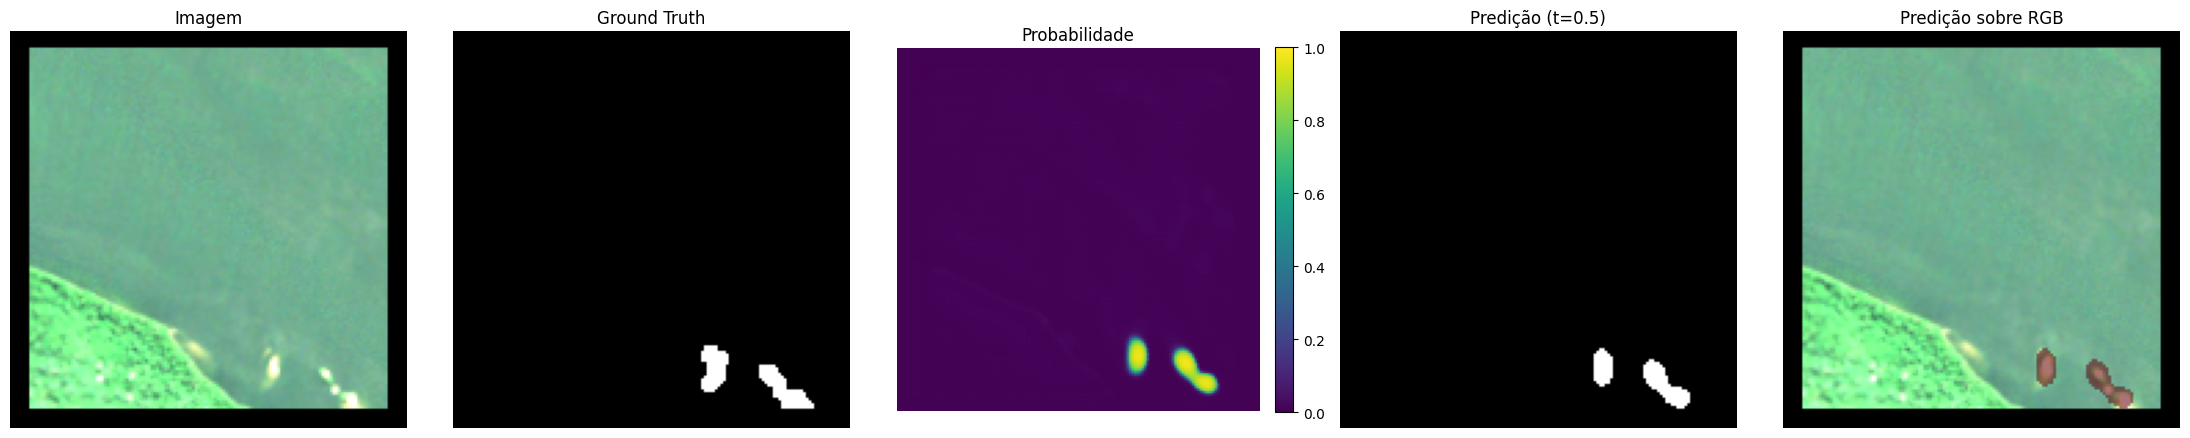

In [20]:
mostrar_positivas_teste(
    test_ds,
    model,
    device,
    threshold=0.5
)